# 城市人口分析与预测

本 Notebook 按优化流水线对 `datasets/` 下的多源人口数据进行处理，预测 **40 个城市（city1~city40）2023 年的总人口数**（常住人口，单位：万人）。

**流水线：** 数据清洗 → 保证城市-年份连续 → 构造高质量人口特征 → 特征精简(170→~70) → 构造历史预测样本 → 严格 Walk-forward OOF → LightGBM 参数优化 → Density Ratio 加入 → Trend/Ridge/CatBoost 辅助 → 获得所有模型 OOF → 真实人口 MSE 评价 → NNLS 优化 Ensemble 权重 → 多步递推回测 → 确定最终模型 → 全部历史数据训练 → 2022→2023 递推 → 后处理 → submission.csv。

**核心思想：** 不直接预测人口，而是预测「下一年人口增长率」 $Growth_{t+1}=(P_{t+1}-P_t)/P_t$，最后 $P_{t+1}=P_t(1+Growth_{t+1})$；人口数据到 2021 年，需两步递推（先 2022、再 2023）。

## 1. 导入依赖

In [13]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from scipy.optimize import nnls

import lightgbm as lgb
from catboost import CatBoostRegressor

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

warnings.filterwarnings("ignore")
pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 200)
%matplotlib inline

def _find_datasets():
    for cand in ["datasets", os.path.join("城市人口分析与预测", "datasets"),
                 os.path.join("..", "datasets"), os.path.join("..", "城市人口分析与预测", "datasets")]:
        if os.path.isdir(cand):
            return cand
    raise FileNotFoundError("未找到 datasets 目录，请用 Jupyter 打开「城市人口分析与预测」目录运行。")

DATA_DIR = _find_datasets()
RANDOM_STATE = 42
print("依赖导入完成，数据目录:", DATA_DIR)

依赖导入完成，数据目录: datasets


## 2. 数据读取（8 个文件合并为主表）

In [14]:
def read_population():
    df = pd.read_excel(os.path.join(DATA_DIR, "人口规模.xlsx"))
    return df.rename(columns={"城市名称": "city_id", "年份": "year",
                              "常住人口（万人）": "population", "户籍人口（万人）": "hukou_population"})[["city_id", "year", "population", "hukou_population"]]

def read_density():
    df = pd.read_excel(os.path.join(DATA_DIR, "人口密度.xlsx"))
    return df.rename(columns={"城市名称": "city_id", "年份": "year", "人口密度（人/平方公里）": "density"})[["city_id", "year", "density"]]

def read_urbanization():
    df = pd.read_excel(os.path.join(DATA_DIR, "城镇化率.xlsx"))
    return df.rename(columns={"城市名称": "city_id", "年份": "year", "urbanizationRate": "urbanization"})[["city_id", "year", "urbanization"]]

def read_employment():
    xl = pd.ExcelFile(os.path.join(DATA_DIR, "就业信息.xlsx"))
    unemp = xl.parse("城镇失业率").rename(columns={"城市名称": "city_id", "年份": "year", "unemploymentRate": "unemployment"})
    emp = xl.parse("从业人员数").rename(columns={"城市名称": "city_id", "年份": "year", "employeesNumber": "employees"})
    ind = xl.parse("第一、二、三产业就业人数").rename(columns={"城市名称": "city_id", "年份": "year", "pi_Employment": "pi_employment", "si_Employment": "si_employment", "ti_Employment": "ti_employment"})
    return (unemp[["city_id", "year", "unemployment"]], emp[["city_id", "year", "employees"]],
            ind[["city_id", "year", "pi_employment", "si_employment", "ti_employment"]])

def read_wage():
    raw = pd.read_excel(os.path.join(DATA_DIR, "工资水平.xlsx"), sheet_name="职工平均工资")
    raw = raw.rename(columns={raw.columns[0]: "year"})
    raw["year"] = raw["year"].astype(str).str.replace("年", "").astype(int)
    return raw.melt(id_vars="year", var_name="city_id", value_name="wage")[["city_id", "year", "wage"]]

def read_age():
    df = pd.read_excel(os.path.join(DATA_DIR, "年龄结构.xlsx"))
    return df.rename(columns={"城市名称": "city_id", "年份": "year", "0-14": "age_0_14", "15-64": "age_15_64", "65+": "age_65_plus"})[["city_id", "year", "age_0_14", "age_15_64", "age_65_plus"]]

def _read_wide_living(sheet, value_col):
    raw = pd.read_excel(os.path.join(DATA_DIR, "生活水平.xlsx"), sheet_name=sheet, header=None)
    years = pd.to_numeric(raw.iloc[1, 1:], errors="coerce").astype(int).values
    cities = raw.iloc[2:, 0].astype(str).str.strip().values
    vals = raw.iloc[2:, 1:].values
    n_city, n_year = vals.shape
    rows = [(cities[i], years[j], vals[i, j]) for i in range(n_city) for j in range(n_year)]
    df = pd.DataFrame(rows, columns=["city_id", "year", value_col])
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    return df

def read_living():
    sheets = {"人均可支配收入": "income", "人均消费支出": "consumption", "城镇居民消费支出": "towner_consumption",
              "农村居民消费支出": "rural_consumption", "城镇居民人均收入": "towner_income", "农村居民人均收入": "rural_income"}
    return {col: _read_wide_living(sh, col) for sh, col in sheets.items()}

def load_all():
    frames = [read_population(), read_density(), read_urbanization()]
    unemp, emp, ind = read_employment()
    frames += [unemp, emp, ind, read_wage(), read_age()]
    frames += list(read_living().values())
    train = frames[0]
    for f in frames[1:]:
        train = train.merge(f, on=["city_id", "year"], how="outer")
    return train

train = load_all()
print("主表形状:", train.shape, " 城市数:", train["city_id"].nunique())

主表形状: (1034, 21)  城市数: 43


## 3. 数据清洗 + 保证城市-年份连续

城市名统一（修正 `ctiy` 录入错误）、按 (城市, 年份) 去重；再把每个城市的年份补全为连续序列，使滞后特征按正确年份计算。

In [15]:
def clean(train):
    train = train.copy()
    train["city_id"] = train["city_id"].astype(str).str.strip()
    train["city_id"] = train["city_id"].str.replace("ctiy", "city", regex=False)
    train["year"] = pd.to_numeric(train["year"], errors="coerce").astype("Int64")
    dup = train.duplicated(subset=["city_id", "year"]).sum()
    if dup:
        print(f"[清洗] 发现重复记录 {dup} 条")
        train = train.groupby(["city_id", "year"], as_index=False).mean(numeric_only=True)
    return train.sort_values(["city_id", "year"]).reset_index(drop=True)

def ensure_continuity(train):
    parts = []
    for city, sub in train.groupby("city_id", sort=False):
        sub = sub.sort_values("year")
        full = pd.DataFrame({"year": range(int(sub["year"].min()), int(sub["year"].max()) + 1)})
        full["city_id"] = city
        full = full.merge(sub, on=["city_id", "year"], how="left")
        parts.append(full)
    return pd.concat(parts, ignore_index=True)

train = ensure_continuity(clean(train))
print("清洗+连续化后:", train.shape, " 城市数:", train["city_id"].nunique())

[清洗] 发现重复记录 117 条
清洗+连续化后: (917, 21)  城市数: 40


## 4. 构造高质量人口特征（170 个）

In [16]:
RAW_COLS = ["population", "hukou_population", "density", "urbanization", "unemployment",
            "employees", "pi_employment", "si_employment", "ti_employment", "wage",
            "income", "consumption", "towner_consumption", "rural_consumption",
            "towner_income", "rural_income", "age_0_14", "age_15_64", "age_65_plus"]

def build_features(df):
    panel = df.copy().sort_values(["city_id", "year"]).reset_index(drop=True)
    for c in ["age_0_14", "age_15_64", "age_65_plus"]:
        panel[c] = panel.groupby("city_id")[c].ffill()

    panel["emp_total"] = panel["pi_employment"] + panel["si_employment"] + panel["ti_employment"]
    panel["pi_share"] = panel["pi_employment"] / panel["emp_total"].replace(0, np.nan)
    panel["si_share"] = panel["si_employment"] / panel["emp_total"].replace(0, np.nan)
    panel["ti_share"] = panel["ti_employment"] / panel["emp_total"].replace(0, np.nan)

    panel["age_total"] = panel["age_0_14"] + panel["age_15_64"] + panel["age_65_plus"]
    panel["child_share"] = panel["age_0_14"] / panel["age_total"].replace(0, np.nan)
    panel["working_share"] = panel["age_15_64"] / panel["age_total"].replace(0, np.nan)
    panel["old_share"] = panel["age_65_plus"] / panel["age_total"].replace(0, np.nan)
    panel["child_dep"] = panel["age_0_14"] / panel["age_15_64"].replace(0, np.nan)
    panel["old_dep"] = panel["age_65_plus"] / panel["age_15_64"].replace(0, np.nan)
    panel["total_dep"] = (panel["age_0_14"] + panel["age_65_plus"]) / panel["age_15_64"].replace(0, np.nan)

    panel["net_inflow"] = panel["population"] - panel["hukou_population"]
    panel["pop_hukou_ratio"] = panel["population"] / panel["hukou_population"].replace(0, np.nan)

    lag_vars = list(dict.fromkeys(RAW_COLS + ["emp_total", "pi_share", "si_share", "ti_share",
        "age_total", "child_share", "working_share", "old_share", "child_dep", "old_dep", "total_dep",
        "net_inflow", "pop_hukou_ratio"]))
    panel = panel.sort_values(["city_id", "year"]).reset_index(drop=True)
    g = panel.groupby("city_id", sort=False)
    for c in lag_vars:
        for k in (1, 2, 3):
            panel[f"{c}_lag{k}"] = g[c].shift(k)
        panel[f"{c}_growth"] = panel[c] / panel[f"{c}_lag1"] - 1.0

    p = panel.groupby("city_id", sort=False)["population"]
    for k in (4, 5, 6):
        panel[f"population_lag{k}"] = p.shift(k)
    panel["pop_growth"] = panel["population"] / panel["population_lag1"] - 1.0
    panel["pop_growth_last"] = panel["population_lag1"] / panel["population_lag2"] - 1.0
    panel["pop_growth_lag2"] = panel["population_lag2"] / panel["population_lag3"] - 1.0
    panel["pop_growth_lag3"] = panel["population_lag3"] / panel["population_lag4"] - 1.0
    panel["pop_growth_lag4"] = panel["population_lag4"] / panel["population_lag5"] - 1.0
    panel["pop_growth_lag5"] = panel["population_lag5"] / panel["population_lag6"] - 1.0
    panel["pop_growth_avg3"] = panel[["pop_growth", "pop_growth_last", "pop_growth_lag2"]].mean(axis=1)
    panel["pop_growth_avg5"] = panel[["pop_growth", "pop_growth_last", "pop_growth_lag2", "pop_growth_lag3", "pop_growth_lag4"]].mean(axis=1)
    return panel.replace([np.inf, -np.inf], np.nan)

def add_target(panel):
    panel = panel.sort_values(["city_id", "year"]).reset_index(drop=True)
    panel["target"] = panel.groupby("city_id", sort=False)["pop_growth"].shift(-1)
    return panel

panel = add_target(build_features(train))
feature_cols = [c for c in panel.columns if c not in ("city_id", "year", "target", "population_growth")]
feature_cols = [c for c in feature_cols if panel[c].notna().any()]
print("原始特征数:", len(feature_cols))

原始特征数: 170


## 5. 构造历史预测样本 + 特征精简（170 → ~70）

In [17]:
samples = panel.dropna(subset=["target"]).reset_index(drop=True)
lo, hi = samples["target"].quantile([0.005, 0.995])
samples["target"] = samples["target"].clip(lo, hi)

def select_features(samples, feature_cols, n_keep=70):
    model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, num_leaves=15,
                              random_state=RANDOM_STATE, verbose=-1)
    model.fit(samples[feature_cols], samples["target"])
    imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    missing_rate = samples[feature_cols].isna().mean()
    keep = [c for c in imp.index if missing_rate[c] <= 0.6]
    return keep[:n_keep], imp

feature_cols, imp = select_features(samples, feature_cols, n_keep=70)
print(f"精简后特征数: {len(feature_cols)}")
print("Top 10 特征:", list(imp.head(10).index))
print(f"训练样本: {len(samples)}")

精简后特征数: 70
Top 10 特征: ['density_growth', 'wage', 'wage_lag3', 'wage_lag2', 'wage_lag1', 'age_0_14_growth', 'pop_growth', 'pop_growth_lag3', 'urbanization', 'density']
训练样本: 642


## 6. 模型定义（LightGBM/CatBoost/Ridge + 趋势 + 密度比例）

In [18]:
def trend_predict(X):
    parts = np.column_stack([X["pop_growth"].values, X["pop_growth_last"].values,
        X["pop_growth_lag2"].values, X["pop_growth_lag3"].values, X["pop_growth_lag4"].values]).astype(float)
    return np.nanmedian(parts, axis=1)

def density_ratio_predict(X):
    return X["density_growth"].values

def make_lgbm(**kw):
    params = dict(n_estimators=400, learning_rate=0.03, num_leaves=15, max_depth=5,
                  min_child_samples=8, subsample=0.85, subsample_freq=1, colsample_bytree=0.8,
                  reg_alpha=0.3, reg_lambda=1.0, random_state=RANDOM_STATE, verbose=-1)
    params.update(kw)
    return lgb.LGBMRegressor(**params)

def make_cat():
    return CatBoostRegressor(iterations=500, learning_rate=0.03, depth=5, l2_leaf_reg=3.0,
                             random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False)

def make_ridge(alpha=10.0):
    return Ridge(alpha=alpha)

def fit_predict_model(model, X_tr, y_tr, X_te):
    if isinstance(model, Ridge):
        imp = SimpleImputer(strategy="median"); sc = StandardScaler()
        model.fit(sc.fit_transform(imp.fit_transform(X_tr)), y_tr)
        return model.predict(sc.transform(imp.transform(X_te)))
    model.fit(X_tr, y_tr)
    return model.predict(X_te)

def predict_growth_row(X_tr, y_tr, X_te, specs):
    out = {}
    for name, mk in specs:
        if name == "trend": out[name] = trend_predict(X_te)
        elif name == "density": out[name] = density_ratio_predict(X_te)
        elif name == "ridge": out[name] = fit_predict_model(make_ridge(), X_tr, y_tr, X_te)
        else: out[name] = fit_predict_model(mk(), X_tr, y_tr, X_te)
    return out

print("模型定义完成")

模型定义完成


## 7. LightGBM 参数优化（小网格 + Walk-forward OOF）

In [19]:
def tune_lgbm(samples, feature_cols, val_years):
    grid = [
        dict(num_leaves=15, min_child_samples=8, learning_rate=0.03, colsample_bytree=0.8),
        dict(num_leaves=31, min_child_samples=8, learning_rate=0.03, colsample_bytree=0.8),
        dict(num_leaves=15, min_child_samples=15, learning_rate=0.03, colsample_bytree=0.8),
        dict(num_leaves=15, min_child_samples=8, learning_rate=0.05, colsample_bytree=0.8),
        dict(num_leaves=15, min_child_samples=8, learning_rate=0.03, colsample_bytree=0.9),
        dict(num_leaves=31, min_child_samples=15, learning_rate=0.03, colsample_bytree=0.9),
        dict(num_leaves=15, min_child_samples=8, learning_rate=0.05, colsample_bytree=0.9),
        dict(num_leaves=31, min_child_samples=8, learning_rate=0.05, colsample_bytree=0.9),
    ]
    best_params, best_score = None, np.inf
    for kw in grid:
        oof = np.full(len(samples), np.nan)
        for vy in val_years:
            tr = samples["year"] < vy; va = samples["year"] == vy
            if va.sum() == 0 or tr.sum() == 0: continue
            m = make_lgbm(**kw)
            m.fit(samples.loc[tr, feature_cols], samples.loc[tr, "target"])
            oof[va.to_numpy()] = m.predict(samples.loc[va, feature_cols])
        p_now = samples["population"].values; p_next = p_now * (1.0 + samples["target"].values)
        pred_pop = p_now * (1.0 + oof)
        mask = np.isfinite(pred_pop) & np.isfinite(p_next)
        mse = mean_squared_error(p_next[mask], pred_pop[mask])
        if mse < best_score: best_score, best_params = mse, kw
    print(f"[调参] 最佳参数: {best_params} (OOF MSE={best_score:.2f})")
    return best_params

val_years = sorted(samples["year"].unique())[-6:]
lgb_params = tune_lgbm(samples, feature_cols, val_years)

[调参] 最佳参数: {'num_leaves': 15, 'min_child_samples': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.8} (OOF MSE=401.44)


## 8. 严格 Walk-forward OOF + 真实人口 MSE 评价

In [20]:
specs = [("lgb", lambda: make_lgbm(**lgb_params)), ("cat", make_cat), ("ridge", make_ridge), ("trend", None), ("density", None)]
names = [n for n, _ in specs]
oof = {n: np.full(len(samples), np.nan) for n in names}
for vy in val_years:
    tr = samples["year"] < vy; va = samples["year"] == vy
    if va.sum() == 0 or tr.sum() == 0: continue
    preds = predict_growth_row(samples.loc[tr, feature_cols], samples.loc[tr, "target"], samples.loc[va, feature_cols], specs)
    for n in names: oof[n][va.to_numpy()] = preds[n]

p_now = samples["population"].values
p_next = p_now * (1.0 + samples["target"].values)
print("--- 各模型 OOF 人口 MSE ---")
for n in names:
    pred_pop = p_now * (1.0 + oof[n])
    mask = np.isfinite(pred_pop) & np.isfinite(p_next)
    print(f"{n:8s}: MSE = {mean_squared_error(p_next[mask], pred_pop[mask]):10.2f}")

--- 各模型 OOF 人口 MSE ---
lgb     : MSE =     401.44
cat     : MSE =     404.81
ridge   : MSE =     478.40
trend   : MSE =     447.34
density : MSE =  229639.30


## 9. NNLS 优化 Ensemble 权重

In [21]:
ensemble_names = [n for n in names if n != "density"]  # 密度模型 NaN 过多且效果差，不参与融合
stack_valid = np.isfinite(p_next) & np.all([np.isfinite(oof[n]) for n in ensemble_names], axis=0)
X_pop = p_now[stack_valid, None] * (1.0 + np.column_stack([oof[n][stack_valid] for n in ensemble_names]))
y_pop = p_next[stack_valid]
w_nn, _ = nnls(X_pop, y_pop)
weights = w_nn / w_nn.sum()
for n, w in zip(ensemble_names, weights):
    print(f"{n:8s}: w = {w:.3f}")
print(f"融合后 OOF 人口 MSE = {mean_squared_error(y_pop, X_pop @ weights):.2f}")

lgb     : w = 0.567
cat     : w = 0.265
ridge   : w = 0.121
trend   : w = 0.048
融合后 OOF 人口 MSE = 398.95


## 10. 多步递推回测 + 全部数据训练 + 2022→2023 递推

In [22]:
def recursive_forecast(base_df, start_year, n_steps, cutoff_year):
    tr = samples[samples["year"] < cutoff_year]
    X_tr = tr[feature_cols]; y_tr = tr["target"]
    base = base_df.copy(); cur_panel = build_features(base); preds = {}
    for step in range(n_steps):
        yr = start_year + step + 1; cur_year = start_year + step
        row = cur_panel[cur_panel["year"] == cur_year].sort_values("city_id").reset_index(drop=True)
        g = predict_growth_row(X_tr, y_tr, row[feature_cols], specs)
        growth = np.nansum(np.column_stack([g[n] for n in ensemble_names]) * weights, axis=1)
        preds[yr] = row["population"].values * (1.0 + growth)
        for city, p in zip(row["city_id"], preds[yr]):
            mask = (base["city_id"] == city) & (base["year"] == yr)
            if mask.any(): base.loc[mask, "population"] = p
            else: base = pd.concat([base, pd.DataFrame([{"city_id": city, "year": yr, "population": p}])], ignore_index=True)
        cur_panel = build_features(base)
    return preds

# 回测：只用 2019 及以前数据（留出 2020、2021）
preds_bt = recursive_forecast(train[train["year"] <= 2019], 2019, 2, cutoff_year=2019)
true_2020 = panel[panel["year"] == 2020].sort_values("city_id")["population"].values
true_2021 = panel[panel["year"] == 2021].sort_values("city_id")["population"].values
print(f"回测 1 步(2020) 人口 MSE = {mean_squared_error(true_2020, preds_bt[2020]):.2f}")
print(f"回测 2 步(2021) 人口 MSE = {mean_squared_error(true_2021, preds_bt[2021]):.2f}")

# 最终：全部历史数据训练，2022→2023 递推
preds = recursive_forecast(train, 2021, 2, cutoff_year=2021)
p_2022, p_2023 = preds[2022], preds[2023]
print("2023 年预测完成")

回测 1 步(2020) 人口 MSE = 1997.58
回测 2 步(2021) 人口 MSE = 3565.14
2023 年预测完成


## 11. 后处理 + 生成提交文件

In [23]:
p_2023 = np.clip(p_2023, 0, None)
print(f"预测值范围: {p_2023.min():.2f} ~ {p_2023.max():.2f}（非负检查通过）")

cities = sorted(train["city_id"].unique())
sub = pd.DataFrame({"city_id": cities, "year": 2023, "pred": np.round(p_2023, 2)})
sub.to_csv("submission.csv", index=False)
print(sub.to_string(index=False))
print("\n已写入 submission.csv（共", len(sub), "个城市）")

预测值范围: 123.02 ~ 1966.86（非负检查通过）
city_id  year    pred
  city1  2023  358.42
 city10  2023  263.74
 city11  2023  588.82
 city12  2023  467.98
 city13  2023  505.01
 city14  2023  288.96
 city15  2023  937.47
 city16  2023  289.89
 city17  2023 1966.86
 city18  2023  568.84
 city19  2023  752.99
  city2  2023  813.51
 city20  2023  237.95
 city21  2023 1332.61
 city22  2023 1015.68
 city23  2023  264.53
 city24  2023 1030.97
 city25  2023 1058.05
 city26  2023  807.84
 city27  2023  557.18
 city28  2023 1108.70
 city29  2023  719.63
  city3  2023 1862.73
 city30  2023  477.86
 city31  2023  494.76
 city32  2023  491.29
 city33  2023 1038.93
 city34  2023  688.54
 city35  2023  710.56
 city36  2023  393.35
 city37  2023  470.13
 city38  2023  419.21
 city39  2023  231.35
  city4  2023  123.02
 city40  2023  340.52
  city5  2023 1396.51
  city6  2023 1004.46
  city7  2023  552.45
  city8  2023  465.97
  city9  2023  633.19

已写入 submission.csv（共 40 个城市）


## 12. 结果可视化

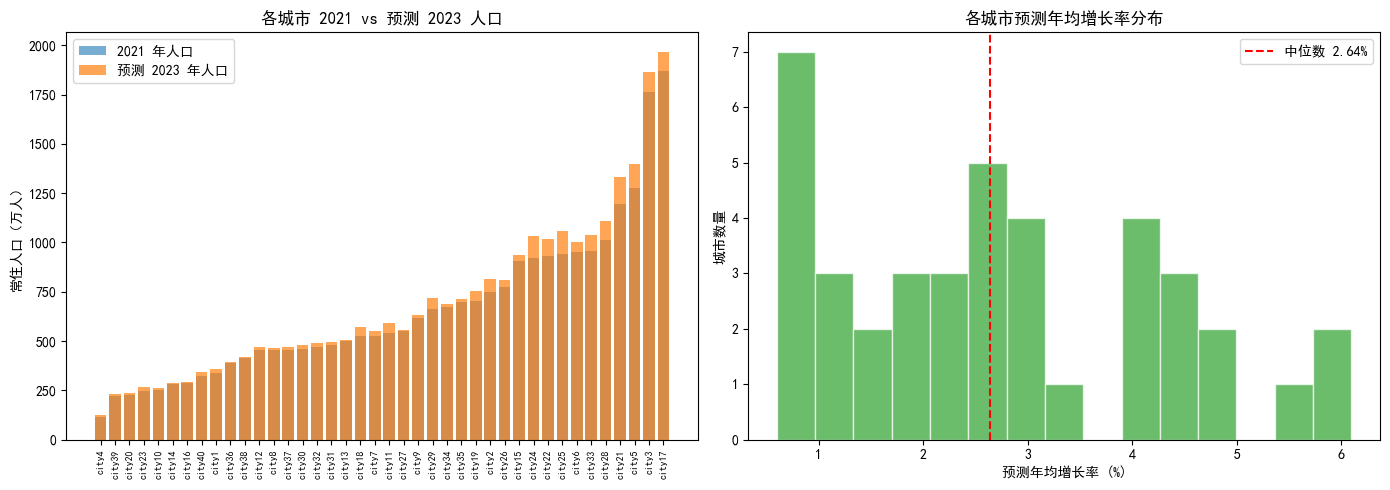

In [24]:
p21 = panel[panel["year"] == 2021].set_index("city_id")["population"].reindex(sub["city_id"]).values
annual_growth = ((sub["pred"].values / p21) ** 0.5 - 1.0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = np.argsort(p21)
axes[0].bar(range(len(sub)), p21[order], alpha=0.6, label="2021 年人口", color="#1f77b4")
axes[0].bar(range(len(sub)), sub["pred"].values[order], alpha=0.7, label="预测 2023 年人口", color="#ff7f0e")
axes[0].set_xticks(range(len(sub))); axes[0].set_xticklabels(sub["city_id"].values[order], rotation=90, fontsize=7)
axes[0].set_ylabel("常住人口（万人）"); axes[0].set_title("各城市 2021 vs 预测 2023 人口"); axes[0].legend()

axes[1].hist(annual_growth, bins=15, color="#2ca02c", alpha=0.7, edgecolor="white")
axes[1].axvline(np.median(annual_growth), color="red", ls="--", label=f"中位数 {np.median(annual_growth):.2f}%")
axes[1].set_xlabel("预测年均增长率 (%)"); axes[1].set_ylabel("城市数量")
axes[1].set_title("各城市预测年均增长率分布"); axes[1].legend()

plt.tight_layout(); plt.show()

## 总结

1. 数据清洗 + 保证城市-年份连续，修正城市名录入错误。
2. 构造 170 个特征，用 LightGBM 特征重要性精简到 70 个。
3. LightGBM 网格调参；CatBoost/Ridge/趋势/密度比例作为辅助与基线。
4. 严格 Walk-forward OOF + 真实人口 MSE 评价 + NNLS 优化融合权重。
5. 多步递推回测验证后，用全部历史数据训练，2022→2023 递推得到最终预测。